# Wafer Map Defect Classification

## Objective
The primary objective of this project is to develop an **Automated Defect Classification** system using **Convolutional Neural Networks (CNN)**. By automatically categorizing spatial defect patterns on wafer maps, the system aims to replace manual inspection, reduce human error, and accelerate the identification of process anomalies.

## Business Value
In semiconductor manufacturing, wafer map patterns provide critical insights into the health of the fabrication process. Specific spatial patterns often correlate with distinct equipment or process failures:
* **Yield Ramp-Up:** Rapid identification of defect clusters (e.g., Scratch, Edge-Ring) allows process engineers to perform **Root Cause Analysis (RCA)** faster.
* **Cost Reduction:** Automating the classification process reduces the "man-to-machine" ratio and minimizes the risk of misclassification due to operator fatigue.
* **Process Monitoring:** Detecting systematic patterns (vs. random defects) helps in pinpointing specific faulty process steps, such as etching uniformity issues or CMP handling errors.

## Data
* **Dataset:** [WM811K Wafer Map](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map).
* **Scale:** Contains over 811,000 wafer maps, with naturally occurring class imbalance (a common challenge in manufacturing data).
* **Features:** The data consists of 2D images where each pixel represents a die's status (0: Background, 1: Good Die, 2: Defective Die).
* **Defect Classes:** 8 specific patterns (Center, Donut, Edge-Loc, Edge-Ring, Loc, Random, Scratch, Near-full) plus a 'None' class.

## Workflow
1.  **Exploratory Data Analysis (EDA):** Analyze class distribution and visualize spatial patterns.
2.  **Data Preprocessing:** Resize wafer maps to a standardized dimension (64x64 / 96x96) and apply denoising techniques.
3.  **Model Architecture:** Design and train a CNN tailored for spatial pattern recognition.
4.  **Error Analysis:** Investigate confusion matrices and "Hot Spots" to understand model limitations.
5.  **Optimization:** Implement Data Augmentation to address class imbalance and improve model generalization.

In [1]:
# Import necessary packages
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings

# Just to make the file clean
warnings.filterwarnings("ignore", message = ".*align should be passed as Python.*")

# Set the random seed
np.random.seed(2026)
tf.random.set_seed(2026)
random.seed(2026)

print("Necessary packages imported")

Necessary packages imported


In [2]:
# Load dataset
df = pd.read_pickle("data/LSWMD.pkl")
print("Dataset loaded successfully")

# Check the shape and columns
print(f"Data Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Inspect few rows. We use .sample() because usually the labeled data is mixed.
print(df.sample(5))

Dataset loaded successfully
Data Shape: (811457, 6)
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']
                                                 waferMap  dieSize   lotName  \
685771  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1233.0  lot42444   
3797    [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1,...    533.0    lot153   
298040  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   2393.0  lot18222   
194023  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   5342.0  lot12297   
319002  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1534.0  lot19353   

        waferIndex trianTestLabel failureType  
685771         6.0       [[Test]]    [[none]]  
3797          23.0   [[Training]]    [[none]]  
298040        23.0             []          []  
194023        20.0             []          []  
319002        13.0             []          []  


In [3]:
# Meaning of each columns
# waferMap: 2D array representing the status of each position on the wafer. 0 means nothing, 1 means good, 2 means bad
# dieSize: How many dies are there in a wafer
# lotName: Lot ID of the wafer 
# waferIndex: Index of the wafer (1 - 25)
# trainTestLabel: Used to split the data
# failureType: Type of failure

# We check what kind of data is stored inside the "failureType" column
print(df["failureType"].apply(str).unique())

["[['none']]" "[['Loc']]" '[]' "[['Edge-Loc']]" "[['Center']]"
 "[['Edge-Ring']]" "[['Scratch']]" "[['Random']]" "[['Near-full']]"
 "[['Donut']]"]


In [4]:
# Now we clean the data 
# We copy the dataset to avoid modifying the original dataset
df_copy = df.copy()

# First we extract the value from nested data 
# and convert data with nothing in their "failureType" to "none"
df_copy["failureType"] = df_copy["failureType"].apply(lambda x: x[0][0] if len(x) > 0 else "none")

# Let's see the distribution between normal and defect wafer 
df_normal = df_copy[df_copy["failureType"] == "none"]
df_defect = df_copy[df_copy["failureType"] != "none"].copy()

print(f"Total samples: {len(df_copy)}")
print(f"Normal samples (none): {len(df_normal)}")
print(f"Defect samples: {len(df_defect)}")


Total samples: 811457
Normal samples (none): 785938
Defect samples: 25519


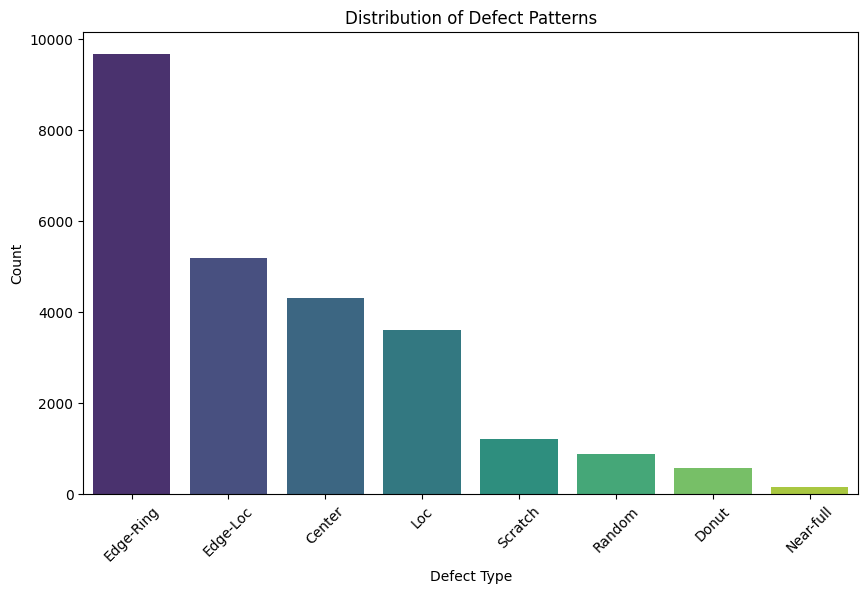


Exact counts of each defect type:
failureType
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [5]:
# Now we visualize the distribution inside the defects
plt.figure(figsize = (10, 6))

defect_counts = df_defect["failureType"].value_counts()

sns.barplot(x = defect_counts.index,
            y = defect_counts.values, 
            palette = "viridis",
            hue = defect_counts.index,
            legend = False)

plt.title("Distribution of Defect Patterns")
plt.xlabel("Defect Type")
plt.ylabel("Count")
plt.xticks(rotation = 45) # Rotate labels for better readability
plt.show()

# 5. Print exact numbers for reference
print("\nExact counts of each defect type:")
print(defect_counts)

Minimum wafer map size: (22, 35)
Maximum wafer map size: (212, 84)


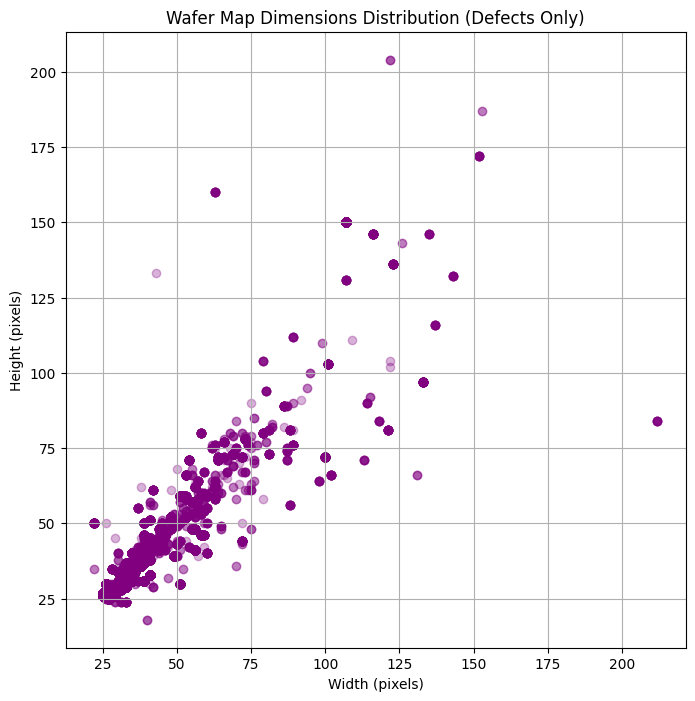

In [6]:
# Before we begin to train the model, we need to check the size of wafer map
# since every wafer map has different die size, we need to pad or resize the wafer map to the same size

# Record size of every wafer map
df_defect["waferMapDim"] = df_defect["waferMap"].apply(lambda x: x.shape)

# Find the maximum and minimum size
max_dim = df_defect["waferMapDim"].max()
min_dim = df_defect["waferMapDim"].min()

print(f"Minimum wafer map size: {min_dim}")
print(f"Maximum wafer map size: {max_dim}")

# Now we visualize the distribution of wafer map sizes 
dim_list = list(df_defect["waferMapDim"])
h_list = [x[0] for x in dim_list]
w_list = [x[1] for x in dim_list]

plt.figure(figsize = (8, 8))
plt.scatter(h_list, w_list, alpha = 0.3, color = "purple")
plt.title("Wafer Map Dimensions Distribution (Defects Only)")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True)
plt.show()

Original shape: (45, 48)
Resized shape: (64, 64)


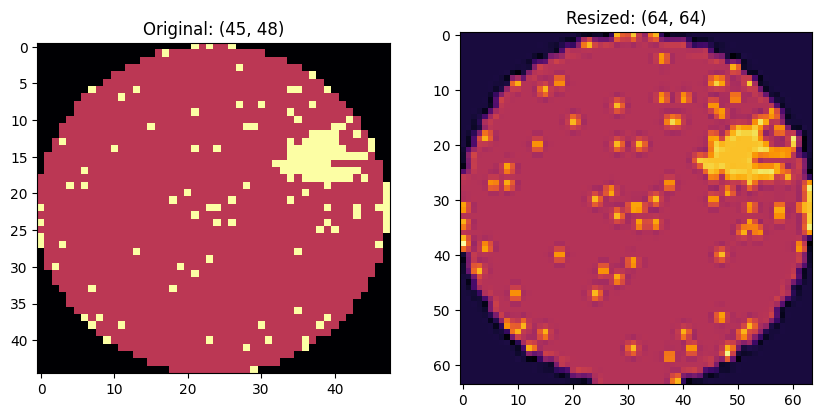

In [7]:
# Since most of the data is in the range of 25*25 to 75*75, we will try to resize them to 64*64 using cv2
TARGET_SIZE_64 = (64, 64)

def resize_wafer_map(wafer_map, TARGET_SIZE):
    """
    Resizes a single wafer map to the target size using Cubic Interpolation.
    """
    # cv2.resize expects pixels to be float or uint8. We cast to float32.
    # The wafer map values are 0, 1, 2.
    # We use cubic interpolation to maintain the quality of the image.
    return cv2.resize(wafer_map.astype(np.float32), TARGET_SIZE, interpolation = cv2.INTER_CUBIC)

# Apply resizing to the entire column
df_defect["waferMapResized"] = df_defect["waferMap"].apply(resize_wafer_map, TARGET_SIZE = TARGET_SIZE_64)

# Verify the change (only check the shape of the first resized image for convenience)
sample_resized = df_defect["waferMapResized"].iloc[0]
print(f"Original shape: {df_defect['waferMap'].iloc[0].shape}")
print(f"Resized shape: {sample_resized.shape}")

# Visualize the comparison (Before vs. After)
plt.figure(figsize = (10, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(df_defect["waferMap"].iloc[0], cmap = "inferno")
plt.title(f"Original: {df_defect['waferMap'].iloc[0].shape}")

# Resized
plt.subplot(1, 2, 2)
plt.imshow(sample_resized, cmap = "inferno")
plt.title(f"Resized: {sample_resized.shape}")

plt.show()

In [8]:
# Now we will finish the data processing part 
# --- X Data (Images) ---
# 1. Stacking: Transform series into Numpy array
X = np.stack(df_defect["waferMapResized"])

# 2. Add Channel Dimension: Add one additional dimension for shade channels
X = np.expand_dims(X, axis = -1)

# 3. Normalization: Compress [0, 1, 2] into just [0, 1]
# We simply divide by 2 to scale the values
X = X.astype("float32") / 2.0

print(f"X (Image) Shape: {X.shape}")

# --- y Data (Labels) ---
# 1. Create dictionary: { "Center": 0, "Donut": 1, ... }
unique_defects = df_defect["failureType"].unique()
label_map = {label: i for i, label in enumerate(unique_defects)}

print("\nLabel Mapping (Category -> Index):")
print(label_map)

# 2. Integer Encoding: Mapping the labels to integers
y_int = df_defect["failureType"].map(label_map).values

# 3. One-Hot Encoding
y = to_categorical(y_int)

print(f"\ny (Label) Shape: {y.shape}")
print(f"Example Label (Original): {df_defect['failureType'].iloc[0]}")
print(f"Example Label (One-Hot): {y[0]}")

X (Image) Shape: (25519, 64, 64, 1)

Label Mapping (Category -> Index):
{np.str_('Loc'): 0, np.str_('Edge-Loc'): 1, np.str_('Center'): 2, np.str_('Edge-Ring'): 3, np.str_('Scratch'): 4, np.str_('Random'): 5, np.str_('Near-full'): 6, np.str_('Donut'): 7}

y (Label) Shape: (25519, 8)
Example Label (Original): Loc
Example Label (One-Hot): [1. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
# Now we train-test split the data
# We choose test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (20415, 64, 64, 1)
X_test shape: (5104, 64, 64, 1)


In [10]:
# Now we can initialize the model
model = Sequential()

# Add Convolutional Layers 
# Layer 1
model.add(Input(shape = (64, 64, 1)))
model.add(Conv2D(32, (3, 3), activation = "relu", padding = "same"))
model.add(MaxPooling2D((2, 2)))

# Layer 2
model.add(Conv2D(64, (3, 3), activation = "relu", padding = "same"))
model.add(MaxPooling2D((2, 2)))

# Layer 3
model.add(Conv2D(128, (3, 3), activation = "relu", padding = "same"))
model.add(MaxPooling2D((2, 2)))

# Add Flatten Layer (Transition from 2D to 1D)
model.add(Flatten())

# Add Dense Layers
model.add(Dense(128, activation = "relu"))
model.add(Dropout(0.5)) # Prevent overfitting by randomly turning off neurons

# Output Layer: 8 neurons for 8 classes, utilizing Softmax
model.add(Dense(8, activation = "softmax"))

# Compile the model
# Loss: Categorical crossentropy is basically mandatory for one-hot encoded targets
# Optimizer: adam is a great default choice
model.compile(optimizer = "adam",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

# Show the summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,408 (4.36 MB)

 Trainable params: 1,142,408 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Finally we train the model
history = model.fit(X_train, y_train,
                    epochs = 10,
                    batch_size = 64,
                    validation_data = (X_test, y_test))

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.7101 - loss: 0.8006 - val_accuracy: 0.8437 - val_loss: 0.4365
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.8362 - loss: 0.4468 - val_accuracy: 0.8454 - val_loss: 0.3986
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.8646 - loss: 0.3650 - val_accuracy: 0.8903 - val_loss: 0.2872
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.8803 - loss: 0.3227 - val_accuracy: 0.9085 - val_loss: 0.2386
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.8990 - loss: 0.2780 - val_accuracy: 0.9173 - val_loss: 0.2253
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9097 - loss: 0.2468 - val_accuracy: 0.9175 - val_loss: 0.2201
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9187 - loss: 0.2207 - val_accuracy: 0.9203 - val_loss: 0.2270
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.9274 - loss: 0.1977 - 

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Prediction completed


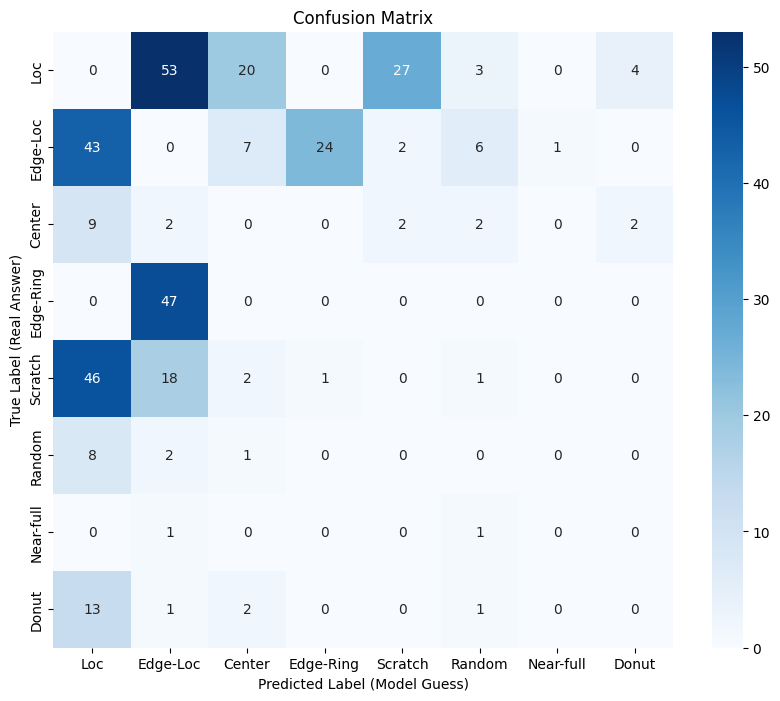

In [12]:
# Althoug the result is quite good, we want to see what's the possible error
# Let the model predict the test set again
y_pred_probs = model.predict(X_test)
print("Prediction completed")

# Convert probabilities to class labels (0~7)
# np.argmax finds the index of the highest probability
y_pred = np.argmax(y_pred_probs, axis = 1)
y_true = np.argmax(y_test, axis = 1)

# Compute Confusion Matrix and set the diagonal to 0 for better visualization
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)

# Plot Heatmap
plt.figure(figsize = (10, 8))

# annot = True: Show numbers in cells
# fmt = "d": Format as integers
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = label_map.keys(),
            yticklabels = label_map.keys())

plt.ylabel("True Label (Real Answer)")
plt.xlabel("Predicted Label (Model Guess)")
plt.title("Confusion Matrix")
plt.show()

## Top 3 Hot Spots:
### True: Loc > Prediction: Edge-Loc

The confusion between "Loc" and "Edge-Loc" suggests the model struggles with spatial boundaries. The down-sampling operations in Max Pooling layers may be causing a loss of fine-grained spatial resolution, leading the model to merge 'Local' defects with the wafer edge boundary.

### True: Edge_Ring > Prediction: Edge-Loc

Misclassifying "Edge-Ring" as "Edge-Loc" indicates the model may not be capturing the full global context of the defect. If the receptive field is too small, the model perceives only a segment of the ring (which looks like a local edge defect) rather than the continuous circular pattern.

### True: Scratch > Prediction: Loc

The misclassification of "Scratch" as "Loc" is likely due to the loss of spatial resolution in deeper layers. As the image passes through successive Max Pooling operations, fine, continuous lines (scratches) can become fragmented into disconnected pixels in the lower-resolution feature maps. 



In [13]:
# Now we process the data again, now resize the images to 96*96 to make the image clearer
# Define the target size
TARGET_SIZE_96 = (96, 96)

# Apply resizing to the entire column
df_defect["waferMapResized_96"] = df_defect["waferMap"].apply(resize_wafer_map, TARGET_SIZE = TARGET_SIZE_96)

# Stacking: Transform series into Numpy array
X_96 = np.stack(df_defect["waferMapResized_96"])

# Add Channel Dimension: Add one additional dimension for shade channels
X_96 = np.expand_dims(X_96, axis = -1)

# Normalization: Compress [0, 1, 2] into just [0, 1]
X_96 = X_96.astype("float32") / 2.0

# Now we train-test split the data again, we don't need to change y since it's the same
X_train_96, X_test_96, y_train, y_test = train_test_split(X_96, y, test_size = 0.2, random_state = 42)

print("Data processed")


Data processed


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,648 (5.98 MB)

 Trainable params: 1,568,648 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 56s 171ms/step - accuracy: 0.7011 - loss: 0.8194 - val_accuracy: 0.8554 - val_loss: 0.4062
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 55s 173ms/step - accuracy: 0.8370 - loss: 0.4394 - val_accuracy: 0.8821 - val_loss: 0.3012
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 179ms/step - accuracy: 0.8734 - loss: 0.3464 - val_accuracy: 0.9103 - val_loss: 0.2550
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 56s 175ms/step - accuracy: 0.8887 - loss: 0.2991 - val_accuracy: 0.9177 - val_loss: 0.2231
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 56s 176ms/step - accuracy: 0.9082 - loss: 0.2509 - val_accuracy: 0.9234 - val_loss: 0.2068
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 56s 176ms/step - accuracy: 0.9162 - loss: 0.2209 - val_accuracy: 0.9261 - val_loss: 0.1887
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 56s 176ms/step - accuracy: 0.9290 - loss: 0.1979 - val_accuracy: 0.9293 - val_loss: 0.1867
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 56s 175ms/step - accuracy: 0.9361 - loss: 0

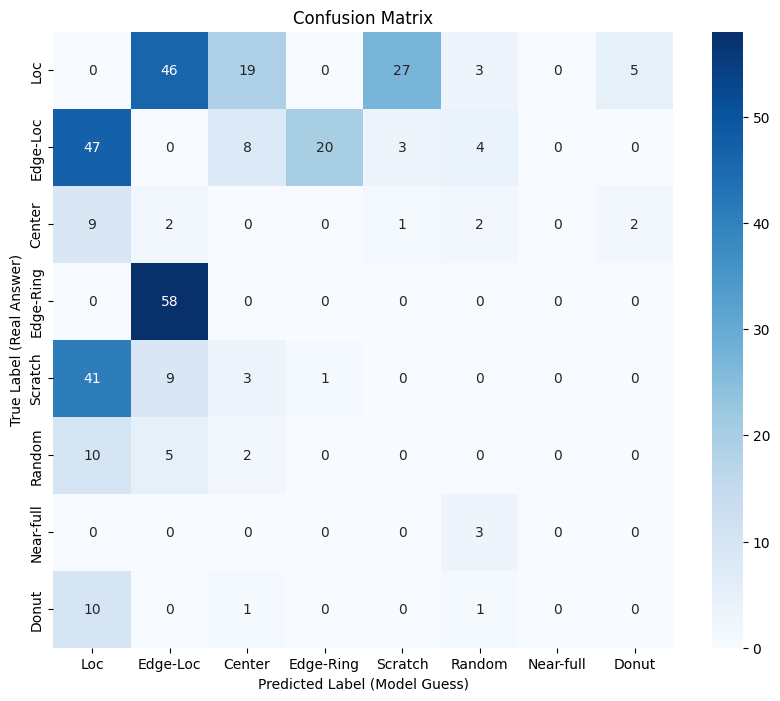

In [14]:
# Now we can nitialize the model again
model_96 = Sequential()

# Add Convolutional Layers 
# Layer 1
model_96.add(Input(shape = (96, 96, 1)))
model_96.add(Conv2D(32, (3, 3), activation = "relu", padding = "same"))
model_96.add(MaxPooling2D((2, 2)))

# Layer 2
model_96.add(Conv2D(64, (3, 3), activation = "relu", padding = "same"))
model_96.add(MaxPooling2D((2, 2)))

# Layer 3
model_96.add(Conv2D(128, (3, 3), activation = "relu", padding = "same"))
model_96.add(MaxPooling2D((2, 2)))

# Adding new layer to avoid overfitting
model_96.add(Conv2D(256, (3, 3), activation = "relu", padding = "same"))
model_96.add(MaxPooling2D((2, 2)))

# Add Flatten Layer (Transition from 2D to 1D)
model_96.add(Flatten())

# Add Dense Layers
model_96.add(Dense(128, activation = "relu"))
model_96.add(Dropout(0.5)) # Prevent overfitting by randomly turning off neurons

# Output Layer: 8 neurons for 8 classes, utilizing Softmax
model_96.add(Dense(8, activation = "softmax"))

# Compile the model
model_96.compile(optimizer = "adam",
                 loss = "categorical_crossentropy",
                 metrics = ["accuracy"])

# Show the summary
model_96.summary()

# Finally we train the model again
history_96 = model_96.fit(X_train_96, y_train,
                          epochs = 10,
                          batch_size = 64,
                          validation_data = (X_test_96, y_test))

# Visualize the result
# Let the model predict the test set again
y_pred_probs_96 = model_96.predict(X_test_96)
print("Prediction completed")

# Convert probabilities to class labels 
# np.argmax finds the index of the highest probability
y_pred_96 = np.argmax(y_pred_probs_96, axis = 1)

# Compute Confusion Matrix and set the diagonal to 0 for better visualization
cm_96 = confusion_matrix(y_true, y_pred_96)
np.fill_diagonal(cm_96, 0)

# Plot Heatmap
plt.figure(figsize = (10, 8))

# annot = True: Show numbers in cells
# fmt = "d": Format as integers
sns.heatmap(cm_96, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = label_map.keys(),
            yticklabels = label_map.keys())

plt.ylabel("True Label (Real Answer)")
plt.xlabel("Predicted Label (Model Guess)")
plt.title("Confusion Matrix")
plt.show()


In [15]:
# To address the observed overfitting and class imbalance, we introduce Geometric Data Augmentation. 
# By applying random rotations, shifts, and flips, we simulate the natural variations found in wafer positioning 
# and improve the model's robustness against invariant features.

# Define the rules
datagen = ImageDataGenerator(rotation_range = 30,
                             shear_range = 0.05,
                             zoom_range = 0.05,
                             horizontal_flip = True,
                             vertical_flip = True,
                             fill_mode = "nearest")

# Use it on 96*96 data
datagen.fit(X_train_96)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,648 (5.98 MB)

 Trainable params: 1,568,648 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.6730 - loss: 0.8854 - val_accuracy: 0.8221 - val_loss: 0.4708
Epoch 2/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 178ms/step - accuracy: 0.8153 - loss: 0.5077 - val_accuracy: 0.8548 - val_loss: 0.3965
Epoch 3/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 178ms/step - accuracy: 0.8419 - loss: 0.4232 - val_accuracy: 0.8860 - val_loss: 0.3140
Epoch 4/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 179ms/step - accuracy: 0.8643 - loss: 0.3680 - val_accuracy: 0.9073 - val_loss: 0.2672
Epoch 5/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 179ms/step - accuracy: 0.8809 - loss: 0.3293 - val_accuracy: 0.9112 - val_loss: 0.2746
Epoch 6/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 58s 182ms/step - accuracy: 0.8927 - loss: 0.2980 - val_accuracy: 0.9197 - val_loss: 0.2359
Epoch 7/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 59s 184ms/step - accuracy: 0.9029 - loss: 0.2795 - val_accuracy: 0.9238 - val_loss: 0.2195
Epoch 8/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.9073 - loss: 0

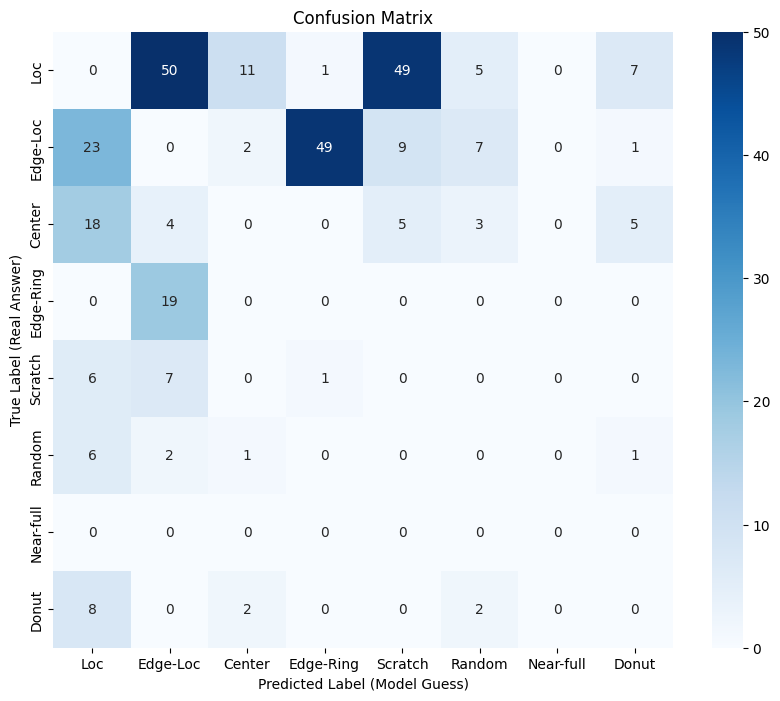

In [16]:
# Now we can nitialize the model again
model_aug = Sequential()

# Add Convolutional Layers 
# Layer 1
model_aug.add(Input(shape = (96, 96, 1)))
model_aug.add(Conv2D(32, (3, 3), activation = "relu", padding = "same"))
model_aug.add(MaxPooling2D((2, 2)))

# Layer 2
model_aug.add(Conv2D(64, (3, 3), activation = "relu", padding = "same"))
model_aug.add(MaxPooling2D((2, 2)))

# Layer 3
model_aug.add(Conv2D(128, (3, 3), activation = "relu", padding = "same"))
model_aug.add(MaxPooling2D((2, 2)))

# Layer 4
model_aug.add(Conv2D(256, (3, 3), activation = "relu", padding = "same"))
model_aug.add(MaxPooling2D((2, 2)))

# Add Flatten Layer (Transition from 2D to 1D)
model_aug.add(Flatten())

# Add Dense Layers
model_aug.add(Dense(128, activation = "relu"))
model_aug.add(Dropout(0.5)) # Prevent overfitting by randomly turning off neurons

# Output Layer: 8 neurons for 8 classes, utilizing Softmax
model_aug.add(Dense(8, activation = "softmax"))

# Compile the model
model_aug.compile(optimizer = "adam",
                 loss = "categorical_crossentropy",
                 metrics = ["accuracy"])

# Show the summary
model_aug.summary()

history_aug = model_aug.fit(datagen.flow(X_train_96, y_train, batch_size = 64),
                            epochs = 20,  # Since the data is more complex now, we run a little more epochs
                            validation_data = (X_test_96, y_test),
                            steps_per_epoch = 319) # To avoid run out of data by directly setting up the number
                            
# Visualize the result
# Let the model predict the test set again
y_pred_probs_aug = model_aug.predict(X_test_96)
print("Prediction completed")

# Convert probabilities to class labels 
# np.argmax finds the index of the highest probability
y_pred_aug = np.argmax(y_pred_probs_aug, axis = 1)

# Compute Confusion Matrix and set the diagonal to 0 for better visualization
cm_aug = confusion_matrix(y_true, y_pred_aug)
np.fill_diagonal(cm_aug, 0)

# Plot Heatmap
plt.figure(figsize = (10, 8))

# annot = True: Show numbers in cells
# fmt = "d": Format as integers
sns.heatmap(cm_aug, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = label_map.keys(),
            yticklabels = label_map.keys())

plt.ylabel("True Label (Real Answer)")
plt.xlabel("Predicted Label (Model Guess)")
plt.title("Confusion Matrix")
plt.show()

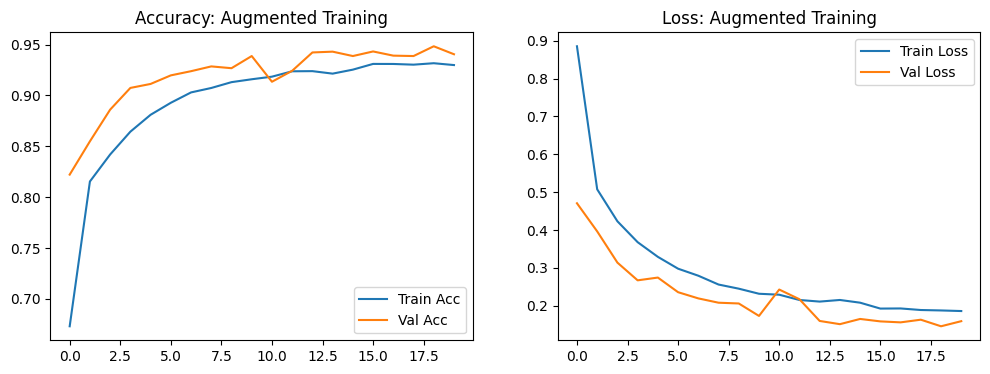

In [17]:
# Visualize the training history
plt.figure(figsize = (12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_aug.history["accuracy"], label = "Train Acc")
plt.plot(history_aug.history["val_accuracy"], label = "Val Acc")
plt.title("Accuracy: Augmented Training")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_aug.history["loss"], label = "Train Loss")
plt.plot(history_aug.history["val_loss"], label = "Val Loss")
plt.title("Loss: Augmented Training")
plt.legend()
plt.show()

# Conclusion & Future Work

## Conclusion

In this project, we successfully developed an end-to-end Automated Defect Classification pipeline for semiconductor wafer maps. By progressing from a baseline CNN (64x64) to a higher-resolution model (96x96), and finally integrating Geometric Data Augmentation, we achieved the following key results:

- **Improved Feature Extraction**: Increasing the input resolution to 96x96 allowed the model to better distinguish fine-grained defect patterns, such as distinguishing "Scratch" from disconnected "Loc" defects.

- **Enhanced Generalization**: While the non-augmented model achieved high accuracy, it showed signs of overfitting (divergence between training and validation loss). The final model, trained with data augmentation, demonstrated superior robustness. The gap between training and validation accuracy narrowed significantly, indicating that the model is well-equipped to handle the rotational and positional variances inherent in real-world fabrication data.

- **Business Impact**: This solution provides a scalable proof-of-concept for replacing manual inspection, potentially reducing the feedback loop time for Excursion Detection in high-volume manufacturing.

## Future Work

To further improve the model's performance and production readiness, the following strategies are recommended:

1. **Transfer Learning**: Instead of training from scratch, leveraging pre-trained architectures like ResNet or VGG16 could help extract more complex features, especially for subtle defect classes like "Edge-Loc".

2. **Handling Class Imbalance**: Although augmentation helped, the dataset remains imbalanced. Implementing Weighted Loss Functions or synthetic data generation (e.g., using GANs or Variational Autoencoders) could further improve the detection rate for minority classes.

3. **Real-time Inference**: Optimizing the model using TensorRT or model quantization to ensure it meets the low-latency requirements of inline wafer inspection tools.
